# Density of population and building ages in Barcelona

## Libraries

In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import mapclassify

plt.style.use('../map.mplstyle')

## Data
Data is obtained from the Open Data Portal of the Ajuntament de Barcelona, and from a curated GitHub repository containing the geographical information on the partitioning of the city in "Districtes", "Barris", and "Seccions Censals".

In [2]:
# from https://opendata-ajuntament.barcelona.cat/data/ca/dataset/est-cadastre-edificacions-edat-mitjana/resource/4b0e0ac1-eade-4055-bea3-f07e2a79a7b4
edat_edificacions_fname = "../data/2026_edificacions_edat_mitjana.csv"

# from https://opendata-ajuntament.barcelona.cat/data/ca/dataset/pad_mdbas/resource/eb82adf2-a7b0-40e6-9624-b4b9eff23018
population_fname = "../data/2025_pad_mdbas.csv"

# from https://github.com/martgnz/bcn-geodata/blob/master/seccio-censal/seccio-censal.geojson
seccio_censal_geojson_fname = "../data/seccio-censal.geojson"

# from https://github.com/martgnz/bcn-geodata/blob/master/barris/barris.geojson
barris_geojson_fname = "../data/barris.geojson"

# from https://github.com/martgnz/bcn-geodata/blob/master/districtes/districtes.geojson
districtes_geojson_fname = "../data/districtes.geojson"

In [3]:
# load seccio_censal geojson file
seccio_censal = gpd.read_file(seccio_censal_geojson_fname)

# fix data type of columns
seccio_censal["SEC_CENS"] = seccio_censal["SEC_CENS"].astype(int)
seccio_censal["BARRI"] = seccio_censal["BARRI"].astype(int)
seccio_censal["DISTRICTE"] = seccio_censal["DISTRICTE"].astype(int)

# select columns we need
seccio_censal = seccio_censal[['SEC_CENS', 'BARRI', 'DISTRICTE', 'AREA', 'geometry']]
seccio_censal.head()

,SEC_CENS,BARRI,DISTRICTE,AREA,geometry
0,1,1,1,226854.317,"POLYGON ((2.17575 41.37827, 2.17577 41.37823, ..."
1,2,1,1,37756.212,"POLYGON ((2.1751 41.37905, 2.17543 41.37877, 2..."
2,3,1,1,40992.088,"POLYGON ((2.1722 41.37692, 2.17265 41.37681, 2..."
3,4,1,1,96760.068,"POLYGON ((2.16962 41.37847, 2.17043 41.37779, ..."
4,5,1,1,60542.195,"POLYGON ((2.17366 41.38071, 2.17407 41.38024, ..."


In [4]:
# load Barris geojson file
barris = gpd.read_file(barris_geojson_fname)

barris["BARRI"] = barris["BARRI"].astype(int)
barris["DISTRICTE"] = barris["DISTRICTE"].astype(int)
barris = barris[['BARRI', 'DISTRICTE', 'NOM', 'geometry']].rename(columns={'NOM':'NOM_BARRI'})
barris.head()

,BARRI,DISTRICTE,NOM_BARRI,geometry
0,1,1,el Raval,"POLYGON ((2.16471 41.38593, 2.16936 41.38554, ..."
1,2,1,el Barri Gòtic,"POLYGON ((2.17701 41.38525, 2.17873 41.38396, ..."
2,3,1,la Barceloneta,"POLYGON ((2.19623 41.38745, 2.19631 41.38745, ..."
3,7,2,la Dreta de l'Eixample,"POLYGON ((2.17091 41.40182, 2.17221 41.40083, ..."
4,8,2,l'Antiga Esquerra de l'Eixample,"POLYGON ((2.15736 41.39331, 2.15847 41.39245, ..."


In [5]:
# load Districtes geojson file
districtes = gpd.read_file(districtes_geojson_fname)
districtes['DISTRICTE'] = districtes['DISTRICTE'].astype(int)
districtes = districtes[['DISTRICTE', 'NOM', 'geometry']].rename(columns={'NOM':'NOM_DISTRICTE'})
districtes.head()

,DISTRICTE,NOM_DISTRICTE,geometry
0,1,Ciutat Vella,"POLYGON ((2.18345 41.39061, 2.18459 41.38976, ..."
1,2,Eixample,"POLYGON ((2.1869 41.40165, 2.18689 41.40087, 2..."
2,3,Sants-Montjuïc,"MULTIPOLYGON (((2.14824 41.37623, 2.14896 41.3..."
3,4,Les Corts,"POLYGON ((2.10342 41.4011, 2.10352 41.40109, 2..."
4,5,Sarrià-Sant Gervasi,"MULTIPOLYGON (((2.07313 41.43522, 2.07319 41.4..."


In [6]:
# load data on the mean age of the construction, keeping only the code of the seccio_censal
# and the data point relative to the mean construction age
edat = pd.read_csv(edat_edificacions_fname)
edat = edat.rename(
    columns={'Seccio_censal':'SEC_CENS', 'Codi_barri':'BARRI', 'Codi_districte':'DISTRICTE'})\
        [['SEC_CENS', 'BARRI', 'DISTRICTE','Edat_mitjana']]
edat.head()

,SEC_CENS,BARRI,DISTRICTE,Edat_mitjana
0,1,1,1,100.4
1,2,1,1,108.7
2,3,1,1,110.8
3,4,1,1,95.4
4,5,1,1,119.6


In [7]:
# load data on the number of people living in each "Secció Censal"
population = pd.read_csv(population_fname)
population['SEC_CENS'] = population['Seccio_Censal'].apply(lambda x:int(str(x)[-3:]))
population = population.rename(columns={'Codi_Districte':'DISTRICTE', 'Valor':'population'})\
    [['DISTRICTE', 'SEC_CENS', 'population']]
population.head()

,DISTRICTE,SEC_CENS,population
0,1,1,1419
1,1,2,1345
2,1,3,3710
3,1,4,3092
4,1,5,2443


In [8]:
# this is the GeoDataFrame that will be used for plotting the maps
gdf = seccio_censal.merge(edat, how='left').merge(population, how='left')
gdf['density'] = gdf['population']/gdf['AREA']
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   SEC_CENS      1068 non-null   int64   
 1   BARRI         1068 non-null   int64   
 2   DISTRICTE     1068 non-null   int64   
 3   AREA          1068 non-null   float64 
 4   geometry      1068 non-null   geometry
 5   Edat_mitjana  1055 non-null   float64 
 6   population    1068 non-null   int64   
 7   density       1068 non-null   float64 
dtypes: float64(3), geometry(1), int64(4)
memory usage: 66.9 KB


## Plots

### Bivariate map

In [9]:
gdf['x_group'] = gdf[['Edat_mitjana']].apply(mapclassify.Quantiles.make(rolling=True, k = 3))
gdf['y_group'] = gdf[['density']].apply(mapclassify.Quantiles.make(rolling=True, k = 3))
gdf['xy_group'] = gdf['x_group'].astype(str) + "-" + gdf['y_group'].astype(str)
gdf.head()

,SEC_CENS,BARRI,DISTRICTE,AREA,geometry,Edat_mitjana,population,density,x_group,y_group,xy_group
0,1,1,1,226854.317,"POLYGON ((2.17575 41.37827, 2.17577 41.37823, ...",100.4,1419,0.006255,2,0,2-0
1,2,1,1,37756.212,"POLYGON ((2.1751 41.37905, 2.17543 41.37877, 2...",108.7,1345,0.035623,2,1,2-1
2,3,1,1,40992.088,"POLYGON ((2.1722 41.37692, 2.17265 41.37681, 2...",110.8,3710,0.090505,2,2,2-2
3,4,1,1,96760.068,"POLYGON ((2.16962 41.37847, 2.17043 41.37779, ...",95.4,3092,0.031955,2,0,2-0
4,5,1,1,60542.195,"POLYGON ((2.17366 41.38071, 2.17407 41.38024, ...",119.6,2443,0.040352,2,1,2-1


In [25]:
color_mapping = {
    "0-0": "#f0f0f0",
    "1-0": "#b3cde3",
    "2-0": "#6497b1",

    "0-1": "#fdbb84",
    "1-1": "#9e9e9e",
    "2-1": "#4f81a3",

    "0-2": "#e34a33",
    "1-2": "#b3588a",
    "2-2": "#2c3e75"
}

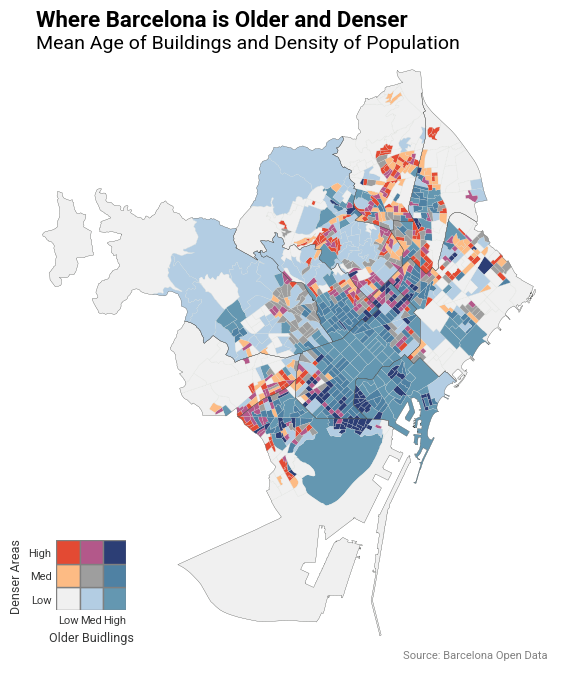

In [31]:
# calculate the max and min of the age of the buildings
import contextily as ctx

# gdf = gdf.to_crs(epsg=3857)
# districtes = districtes.to_crs(epsg=3857)

scale = 0.7
fig, ax = plt.subplots(figsize=(scale*10, scale*12))
gdf.plot(
    categorical = True,
    edgecolor = "xkcd:light grey",
    linewidth = 0.2,
    linestyle='--',
    ax = ax,
    color=gdf["xy_group"].map(color_mapping),
).set_axis_off();

districtes.plot(
    ax=ax,
    facecolor='none',
    edgecolor='k',
    linewidth=0.15)

# ctx.add_basemap(
#     ax,
#     source=ctx.providers.CartoDB.Positron,
#     alpha=0.5  # key: keep it subtle
# )

# --- Create inset axis for legend ---
legend_ax = fig.add_axes([0.18, 0.18, 0.1, 0.1])  # [left, bottom, width, height]
legend_ax.set_aspect('equal')

# --- Build 3x3 color grid ---
legend_grid = np.array([
    ["0-0", "1-0", "2-0"],
    ["0-1", "1-1", "2-1"],
    ["0-2", "1-2", "2-2"]
])

color_grid = [[color_mapping[cell] for cell in row] for row in legend_grid]

# --- Plot as image ---
for i in range(3):
    for j in range(3):
        legend_ax.add_patch(plt.Rectangle(
            (j, i), 1, 1,
            facecolor=color_grid[i][j],
            edgecolor='gray'
        ))

legend_ax.set_xlim(0, 3)
legend_ax.set_ylim(0, 3)

# Remove ticks
legend_ax.set_xticks([])
legend_ax.set_yticks([])

# --- Axis labels ---
legend_ax.set_xlabel("Older Buidlings", fontsize=9)
legend_ax.set_ylabel("Denser Areas", fontsize=9)

legend_ax.set_xticks([0.5, 1.5, 2.5])
legend_ax.set_xticklabels(["Low", "Med", "High"], fontsize=8)
legend_ax.tick_params('both', length=0)

legend_ax.set_yticks([0.5, 1.5, 2.5])
legend_ax.set_yticklabels(["Low", "Med", "High"], fontsize=8)

# Clean frame
for spine in legend_ax.spines.values():
    spine.set_visible(False)

ax.text(
    2.05, 41.48, "Where Barcelona is Older and Denser",
    fontsize=16, weight='bold'
)

ax.text(
    2.05, 41.474, "Mean Age of Buildings and Density of Population",
    fontsize=14
)

ax.text(
    0.71, 0.01,
    "Source: Barcelona Open Data",
    transform=ax.transAxes,
    fontsize=8,
    color="gray"
)

fig.savefig('map.png', bbox_inches='tight', dpi=600)
ax.axis('off')
plt.show()

Text(0, 0.5, 'Mean density of population (hab/m²)')

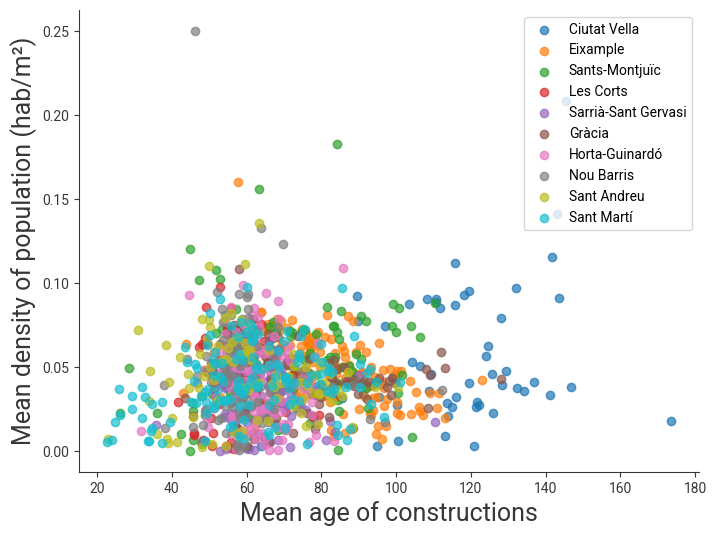

In [11]:
plot_df = population_gdf.merge(df).merge(districtes[['DISTRICTE', 'NOM_DISTRICTE']], on='DISTRICTE')

fig, ax = plt.subplots(figsize=(8,6))
for districte in plot_df['DISTRICTE'].unique():
    tmp = plot_df[plot_df['DISTRICTE']==districte]
    nom_districte = districtes.set_index('DISTRICTE')['NOM_DISTRICTE'][districte]
    ax.scatter(tmp['Edat_mitjana'], tmp['density'], label=nom_districte, alpha=0.7)

ax.legend(loc='upper right', frameon=True)

ax.set_xlabel("Mean age of constructions")
ax.set_ylabel("Mean density of population (hab/m²)")

Text(0, 0.5, 'Mean density of population (hab/m²)')

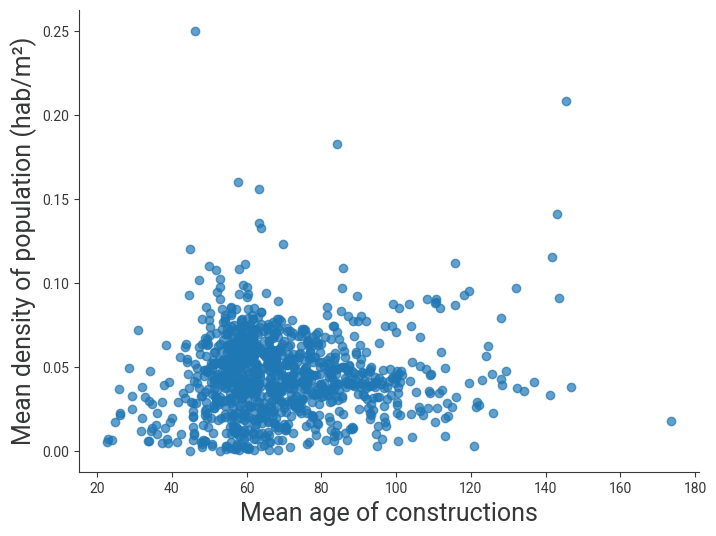

In [12]:
plot_df = population_gdf.merge(df).merge(districtes[['DISTRICTE', 'NOM_DISTRICTE']], on='DISTRICTE')

fig, ax = plt.subplots(figsize=(8,6))

ax.scatter(plot_df['Edat_mitjana'], plot_df['density'], alpha=0.7)

ax.set_xlabel("Mean age of constructions")
ax.set_ylabel("Mean density of population (hab/m²)")

In [13]:
barris_df = pd.DataFrame({
    'area':seccio_censal.groupby('BARRI').AREA.sum(),
    'Edat_mitjana':df.groupby('BARRI').Edat_mitjana.mean(),
    'population':population.merge(seccio_censal).groupby('BARRI')['population'].sum()
}).reset_index()
barris_df['density'] = barris_df['population']/barris_df['area']
barris_df = barris_df.merge(barris[['BARRI', 'DISTRICTE', 'NOM_BARRI']])\
    .merge(districtes[['DISTRICTE', 'NOM_DISTRICTE']])
barris_df

,BARRI,area,Edat_mitjana,population,density,DISTRICTE,NOM_BARRI,NOM_DISTRICTE
0,1,1100286.139,119.895238,49917,0.045367,1,el Raval,Ciutat Vella
1,2,815593.939,131.933333,27878,0.034181,1,el Barri Gòtic,Ciutat Vella
2,3,1179381.956,92.836364,14749,0.012506,1,la Barceloneta,Ciutat Vella
3,4,1109668.776,118.576923,22767,0.020517,1,"Sant Pere, Santa Caterina i la Ribera",Ciutat Vella
4,5,929355.787,70.425000,36621,0.039405,2,el Fort Pienc,Eixample
...,...,...,...,...,...,...,...,...
68,69,1226952.564,33.271429,13691,0.011159,10,Diagonal Mar i el Front Marítim del Poblenou,Sant Martí
69,70,1208701.464,54.375000,30724,0.025419,10,el Besòs i el Maresme,Sant Martí
70,71,1085739.627,53.480000,21902,0.020172,10,Provençals del Poblenou,Sant Martí
71,72,733989.017,61.487500,26976,0.036753,10,Sant Martí de Provençals,Sant Martí


Text(0, 0.5, 'Mean density of population (hab/m²)')

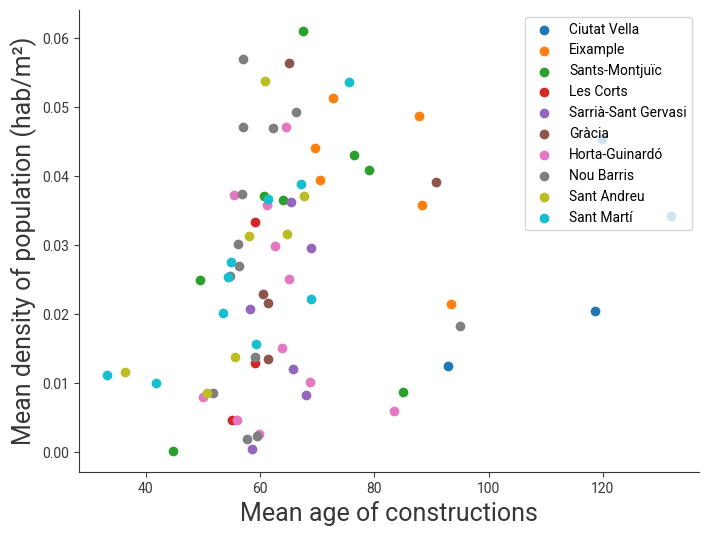

In [14]:
fig, ax = plt.subplots(figsize=(8,6))
for districte in barris_df['DISTRICTE'].unique():
    tmp = barris_df[barris_df['DISTRICTE']==districte]
    nom_districte = districtes.set_index('DISTRICTE')['NOM_DISTRICTE'][districte]
    ax.scatter(tmp['Edat_mitjana'], tmp['density'], label=nom_districte)

ax.legend(loc='upper right', frameon=True)

ax.set_xlabel("Mean age of constructions")
ax.set_ylabel("Mean density of population (hab/m²)")

Text(120, 250, 'Mean = 69.4')

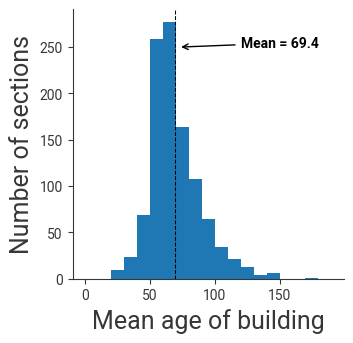

In [15]:
fig, ax = plt.subplots(figsize=(3.5,3.5))
plot_df.Edat_mitjana.hist(grid=False, bins=np.arange(20)*10)
ax.set_xlabel("Mean age of building")
ax.set_ylabel("Number of sections")
m = plot_df.Edat_mitjana.mean()
ax.axvline(x=m, color='k', linestyle='--', linewidth=0.75)

y = 250
ax.annotate(
    f"Mean = {m:.1f}",
    xy=(72, y),
    xytext=(120, y),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10,
    weight='bold'
)

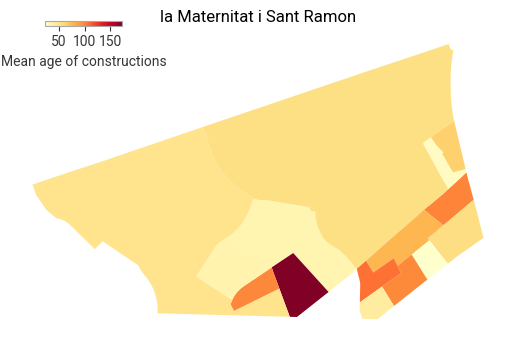

In [16]:
def barrio_plot(barrio):
    fig, ax = plt.subplots()
    barrio.plot(ax=ax, column='Edat_mitjana', cmap='YlOrRd')
    ax.axis(False)
    ax.set_title(barrio['NOM_BARRI'].unique()[0])

    # color bar
    cax = fig.add_axes([0.18, 0.82, 0.12, 0.01])
    m, M = df.Edat_mitjana.min(), df.Edat_mitjana.max()
    sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(vmin=m, vmax=M))
    sm._A = []
    cbar = plt.colorbar(sm, cax=cax, drawedges=False, orientation="horizontal")
    cbar.outline.set_edgecolor('darkgray')
    cbar.set_label("Mean age of constructions", fontsize=10)


gdf = seccio_censal.merge(df).merge(barris[['BARRI', 'NOM_BARRI']])

barrio_id = 20
barrio = gpd.GeoDataFrame(gdf[gdf.BARRI == barrio_id])
barrio_plot(barrio)
# for barrio_id in gdf['BARRI'].unique():
#     barrio = gpd.GeoDataFrame(gdf[gdf.BARRI == barrio_id])
#     barrio_plot(barrio)

,BARRI,NOM_BARRI,DISTRICTE,geometry
0,1,el Raval,1,"POLYGON ((2.16471 41.38593, 2.16936 41.38554, ..."
1,2,el Barri Gòtic,1,"POLYGON ((2.17701 41.38525, 2.17873 41.38396, ..."
2,3,la Barceloneta,1,"POLYGON ((2.19623 41.38745, 2.19631 41.38745, ..."
3,7,la Dreta de l'Eixample,2,"POLYGON ((2.17091 41.40182, 2.17221 41.40083, ..."
4,8,l'Antiga Esquerra de l'Eixample,2,"POLYGON ((2.15736 41.39331, 2.15847 41.39245, ..."
...,...,...,...,...
68,50,les Roquetes,8,"POLYGON ((2.18315 41.45279, 2.18312 41.45271, ..."
69,53,la Trinitat Nova,8,"POLYGON ((2.18872 41.45504, 2.18878 41.45484, ..."
70,54,Torre Baró,8,"POLYGON ((2.18137 41.46144, 2.18173 41.46103, ..."
71,55,Ciutat Meridiana,8,"POLYGON ((2.17959 41.46406, 2.17998 41.46357, ..."


In [26]:
gdf.merge(barris, on=["BARRI", "DISTRICTE"])

,id,SEC_CENS,BARRI,DISTRICTE,AREA,geometry_x,Edat_mitjana,NOM_BARRI,geometry_y
0,0,1,1,1,226854.317,"POLYGON ((2.17575 41.37827, 2.17577 41.37823, ...",100.4,el Raval,"POLYGON ((2.16471 41.38593, 2.16936 41.38554, ..."
1,1,2,1,1,37756.212,"POLYGON ((2.1751 41.37905, 2.17543 41.37877, 2...",108.7,el Raval,"POLYGON ((2.16471 41.38593, 2.16936 41.38554, ..."
2,2,3,1,1,40992.088,"POLYGON ((2.1722 41.37692, 2.17265 41.37681, 2...",110.8,el Raval,"POLYGON ((2.16471 41.38593, 2.16936 41.38554, ..."
3,3,4,1,1,96760.068,"POLYGON ((2.16962 41.37847, 2.17043 41.37779, ...",95.4,el Raval,"POLYGON ((2.16471 41.38593, 2.16936 41.38554, ..."
4,4,5,1,1,60542.195,"POLYGON ((2.17366 41.38071, 2.17407 41.38024, ...",119.6,el Raval,"POLYGON ((2.16471 41.38593, 2.16936 41.38554, ..."
...,...,...,...,...,...,...,...,...,...
1050,1050,16,19,4,26533.586,"POLYGON ((2.14156 41.38653, 2.14264 41.38562, ...",55.9,les Corts,"POLYGON ((2.13747 41.39144, 2.13877 41.39124, ..."
1051,1051,90,27,5,52964.068,"POLYGON ((2.14645 41.40951, 2.14719 41.40859, ...",68.9,el Putxet i el Farró,"POLYGON ((2.14838 41.40699, 2.14848 41.4069, 2..."
1052,1052,91,27,5,40719.053,"POLYGON ((2.14315 41.41149, 2.14447 41.41138, ...",66.5,el Putxet i el Farró,"POLYGON ((2.14838 41.40699, 2.14848 41.4069, 2..."
1053,1053,92,27,5,162177.819,"POLYGON ((2.14264 41.41083, 2.1427 41.41082, 2...",63.2,el Putxet i el Farró,"POLYGON ((2.14838 41.40699, 2.14848 41.4069, 2..."


In [30]:
df.groupby('BARRI').Edat_mitjana.max()

BARRI
1     146.9
2     173.5
3     110.6
4     134.1
5      86.9
      ...  
69     49.3
70     78.0
71     70.4
72    101.1
73     86.9
Name: Edat_mitjana, Length: 73, dtype: float64